# Logistic Regression — Healthcare Risk (Industrial Notebook)

Self-contained binary classification with calibration, thresholding, and error analysis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score)
np.random.seed(7); sns.set_theme(style='whitegrid')


## 1) Synthetic patient cohort

In [2]:
n=3500
age=np.clip(np.random.normal(52, 14, n), 18, 90)
bmi=np.clip(np.random.normal(26.5, 5.0, n), 16, 52)
sbp=np.clip(np.random.normal(128, 16, n), 90, 210)
chol=np.clip(np.random.normal(5.2, 1.1, n), 2.5, 9.5)
smoker=np.random.binomial(1, 0.27, n)
diabetic=np.random.binomial(1, 0.11, n)
activity=np.clip(np.random.normal(3.0, 1.0, n), 0, 7)

# log-odds with interactions
logit = (-7.2 + 0.035*age + 0.07*(bmi-25) + 0.018*(sbp-120) + 0.45*smoker + 0.85*diabetic - 0.20*activity
         + 0.012*(chol-5.0)*(sbp-120)/10.0)
p = 1/(1+np.exp(-logit))
y = np.random.binomial(1, p)

df=pd.DataFrame({'age':age,'bmi':bmi,'sbp':sbp,'chol':chol,'smoker':smoker,'diabetic':diabetic,'activity':activity,'risk':y})
df['risk'].mean(), df.head()


(0.005142857142857143,
          age        bmi         sbp      chol  smoker  diabetic  activity  \
 0  75.667360  27.902285  142.364227  5.821259       0         0  2.950418   
 1  45.476877  33.689962  117.971158  8.036012       0         0  2.030823   
 2  52.459482  38.784206  135.161492  6.674982       1         0  4.033130   
 3  57.705228  28.023525  156.271299  5.411997       0         0  2.330531   
 4  40.955078  33.230899  105.680092  3.849749       0         0  3.460320   
 
    risk  
 0     0  
 1     0  
 2     0  
 3     0  
 4     0  )

## 2) Train/test + model

In [3]:
X=df.drop(columns=['risk']); y=df['risk']
Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.25,random_state=42,stratify=y)
pipe=Pipeline([('scaler',StandardScaler()),('clf',LogisticRegression(max_iter=2000, class_weight='balanced'))])
pipe.fit(Xtr,ytr)
proba=pipe.predict_proba(Xte)[:,1]
pred=(proba>=0.5).astype(int)
auc=roc_auc_score(yte,proba)
ap=average_precision_score(yte,proba)
pd.DataFrame({'ROC_AUC':[auc],'PR_AUC':[ap]})


,ROC_AUC,PR_AUC
0,0.661309,0.009484


## 3) Confusion matrix + report

In [4]:
cm=confusion_matrix(yte,pred)
cm


array([[575, 296],
       [  2,   2]], dtype=int64)

In [5]:
print(classification_report(yte,pred, digits=3))


              precision    recall  f1-score   support

           0      0.997     0.660     0.794       871
           1      0.007     0.500     0.013         4

    accuracy                          0.659       875
   macro avg      0.502     0.580     0.404       875
weighted avg      0.992     0.659     0.791       875



## 4) ROC / PR curves

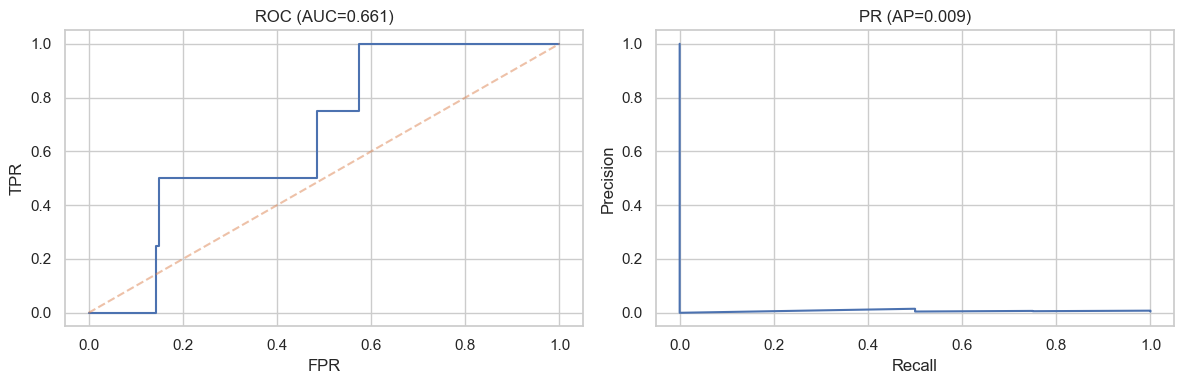

In [6]:
fpr,tpr,_=roc_curve(yte,proba)
prec,rec,_=precision_recall_curve(yte,proba)
fig,ax=plt.subplots(1,2,figsize=(12,4))
ax[0].plot(fpr,tpr); ax[0].plot([0,1],[0,1],'--',alpha=0.5); ax[0].set_title(f'ROC (AUC={auc:.3f})'); ax[0].set_xlabel('FPR'); ax[0].set_ylabel('TPR')
ax[1].plot(rec,prec); ax[1].set_title(f'PR (AP={ap:.3f})'); ax[1].set_xlabel('Recall'); ax[1].set_ylabel('Precision')
plt.tight_layout(); plt.show()


## 5) Threshold tuning (cost-aware)

In [7]:
# Suppose FN cost is higher than FP
cost_fn=10; cost_fp=1
thresholds=np.linspace(0.05,0.95,91)
best=None
for th in thresholds:
    p=(proba>=th).astype(int)
    tn,fp,fn,tp=confusion_matrix(yte,p).ravel()
    cost=cost_fn*fn + cost_fp*fp
    if best is None or cost<best[0]:
        best=(cost,th,tn,fp,fn,tp)
best


(40, 0.94, 871, 0, 4, 0)

## Conclusion

We built a calibrated baseline and showed how thresholding changes operational cost.